# Phase 6 — Comparative Analysis

Compares training frequency patterns and progression shape against a reference lifter's dataset:
["721 Weight Training Workouts" by joep89](https://www.kaggle.com/datasets/joep89/weightlifting/data) (Kaggle).

No bodyweight/age is available for the reference lifter, so this notebook deliberately avoids
absolute-strength comparisons. Instead it looks at two things that don't need normalization by
bodyweight: **training frequency patterns** and the **shape** of strength progression over time
(indexed to each lifter's own peak, aligned by weeks since their own first logged set).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

RAW_FILE = Path("../data/raw/weightlifting_721_workouts.csv")
assert RAW_FILE.exists(), "weightlifting_721_workouts.csv not found in data/raw/"

CLEAN_DIR = Path("../data/clean")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

LB_TO_KG = 0.453592


## 1. Load & clean the reference dataset

Same schema *style* as the Strong export (one row per set, a workout's rows share one `Date`
timestamp), but not identical:
- No `Workout #` → derive `workout_id` from `Date`.
- No `Duration (sec)` → no duration-based workout filter available.
- `Weight` is in **pounds**, not kg.
- `Set Order` is always numeric (no `W`/`Rest Timer`/`Note` rows), but the dataset contains cardio rows
  (e.g. `Cycling`) with `weight == 0` and `reps == 0`, which fall out via the same `reps > 0` invariant
  used in Phase 1.
- Exercise names have inconsistent whitespace/casing (`"Bicep Curl (barbell )"`).

In [2]:
raw_ref = pd.read_csv(RAW_FILE)

print(f"Rows: {len(raw_ref):,}  |  Columns: {raw_ref.shape[1]}")
raw_ref.head(3)


Rows: 9,932  |  Columns: 10


,Date,Workout Name,Exercise Name,Set Order,Weight,Reps,Distance,Seconds,Notes,Workout Notes
0,2015-10-23 17:06:37,Chest,Incline Bench Press (Barbell),1,135.00,8,0.00,0,NaN,NaN
1,2015-10-23 17:06:37,Chest,Incline Bench Press (Barbell),2,135.00,8,0.00,0,NaN,NaN
2,2015-10-23 17:06:37,Chest,Incline Bench Press (Barbell),3,135.00,5,0.00,0,NaN,NaN


In [3]:
COLUMN_MAP = {
    "Date": "date",
    "Workout Name": "workout_name",
    "Exercise Name": "exercise_name",
    "Set Order": "set_order",
    "Weight": "weight_lb",
    "Reps": "reps",
    "Notes": "notes",
}

ref = raw_ref.rename(columns=COLUMN_MAP)[list(COLUMN_MAP.values())]

# Normalize exercise names: strip stray whitespace only, no fuzzy-merging of variants
ref["exercise_name"] = ref["exercise_name"].str.strip()

ref = ref.assign(
    date=pd.to_datetime(ref["date"], errors="coerce"),
    set_order=pd.to_numeric(ref["set_order"], errors="coerce").astype("Int64"),
    weight_lb=pd.to_numeric(ref["weight_lb"], errors="coerce"),
    reps=pd.to_numeric(ref["reps"], errors="coerce").astype("Int64"),
)

print(f"Rows after type casting: {len(ref):,}")


Rows after type casting: 9,932


In [4]:
# Drop rows without usable weight/reps, and non-lifting rows (reps == 0, e.g. Cycling)
before = len(ref)
ref = ref.dropna(subset=["date", "weight_lb", "reps"]).copy()
ref = ref[ref["reps"] > 0].copy()
print(f"Dropped {before - len(ref):,} rows (missing values or non-lifting entries, e.g. cardio)")
print(f"Remaining: {len(ref):,}")

# Convert to kg, matching the own dataset's unit
ref["weight_kg"] = ref["weight_lb"] * LB_TO_KG

# Derive workout_id: rows belonging to the same workout share one exact timestamp
ref["workout_id"] = ref["date"].factorize()[0] + 1
print(f"Derived {ref['workout_id'].nunique():,} workouts from {ref['date'].nunique():,} distinct timestamps")


Dropped 22 rows (missing values or non-lifting entries, e.g. cardio)
Remaining: 9,910
Derived 583 workouts from 583 distinct timestamps


In [5]:
# Per-exercise outlier check: flag sets whose weight is far outside that exercise's own
# distribution (a single global cutoff doesn't work — normal ranges vary hugely by movement)
p99 = ref.groupby("exercise_name")["weight_lb"].transform(lambda s: s.quantile(0.99))
outlier_mask = ref["weight_lb"] > p99 * 3

outliers = ref[outlier_mask]
if len(outliers) > 0:
    print(f"Removing {len(outliers)} outlier row(s):")
    print(outliers[["date", "exercise_name", "weight_lb", "reps"]].to_string(index=False))
else:
    print("No outliers found.")

ref = ref[~outlier_mask].copy()
print(f"\nWorking sets after outlier removal: {len(ref):,}")


Removing 1 outlier row(s):
               date   exercise_name  weight_lb  reps
2017-02-04 19:03:35 Squat (Barbell)    2956.00     6

Working sets after outlier removal: 9,909


In [6]:
# Workout-level quality filter: no duration field here, so use set count only
# (Phase 1 used duration + set count; duration isn't available for this dataset)
sets_per_workout = ref.groupby("workout_id")["set_order"].transform("count")
valid_mask = sets_per_workout >= 5

n_excluded = ref.loc[~valid_mask, "workout_id"].nunique()
print(f"Excluding {n_excluded} workout(s) with fewer than 5 sets")

ref = ref[valid_mask].copy()
print(f"Working sets after workout-quality filter: {len(ref):,}")
print(f"Workouts remaining: {ref['workout_id'].nunique():,}")


Excluding 1 workout(s) with fewer than 5 sets
Working sets after workout-quality filter: 9,905
Workouts remaining: 582


In [7]:
ref = ref.assign(
    volume_kg=ref["weight_kg"] * ref["reps"],
    # Same Epley formula as Phase 1 — values must be comparable between the two datasets
    estimated_1rm=np.where(
        ref["reps"] == 1,
        ref["weight_kg"],
        ref["weight_kg"] * (1 + ref["reps"] / 30),
    ),
    year=ref["date"].dt.year,
    month=ref["date"].dt.to_period("M").astype(str),
    week=ref["date"].dt.to_period("W").astype(str),
    day_of_week=ref["date"].dt.day_name(),
)

REF_COLUMNS = [
    "workout_id", "date", "workout_name", "year", "month", "week", "day_of_week",
    "exercise_name", "set_order", "weight_kg", "reps",
    "volume_kg", "estimated_1rm",
    "notes",
]

reference_sets = ref[REF_COLUMNS].sort_values(["date", "workout_id", "exercise_name", "set_order"])

reference_sets_path = CLEAN_DIR / "reference_sets.csv"
reference_sets.to_csv(reference_sets_path, index=False)
print(f"Exported {len(reference_sets):,} rows -> {reference_sets_path}")


Exported 9,905 rows -> ..\data\clean\reference_sets.csv


## 2. Load own cleaned data

Already produced by `01_cleaning.ipynb` — no changes needed.

In [8]:
own = pd.read_csv("../data/clean/clean_sets.csv", parse_dates=["date"])
print(f"Own dataset:       {len(own):,} sets, {own['date'].min().date()} -> {own['date'].max().date()}")
print(f"Reference dataset: {len(reference_sets):,} sets, {reference_sets['date'].min():%Y-%m-%d} -> {reference_sets['date'].max():%Y-%m-%d}")


Own dataset:       17,397 sets, 2020-05-28 -> 2026-05-27
Reference dataset: 9,905 sets, 2015-10-23 -> 2018-09-29


## 3. Training frequency comparison

No bodyweight/age needed — just how often and on which days each lifter trained.

In [9]:
def workouts_per_week(df: pd.DataFrame) -> pd.Series:
    workout_dates = df.groupby("workout_id")["date"].first()
    return workout_dates.dt.to_period("W").value_counts().sort_index()

own_weekly = workouts_per_week(own)
ref_weekly = workouts_per_week(reference_sets)

print("Own workouts/week:       mean={:.2f}  median={:.1f}  max={}".format(
    own_weekly.mean(), own_weekly.median(), own_weekly.max()))
print("Reference workouts/week: mean={:.2f}  median={:.1f}  max={}".format(
    ref_weekly.mean(), ref_weekly.median(), ref_weekly.max()))


Own workouts/week:       mean=2.75  median=3.0  max=7
Reference workouts/week: mean=4.04  median=4.0  max=6


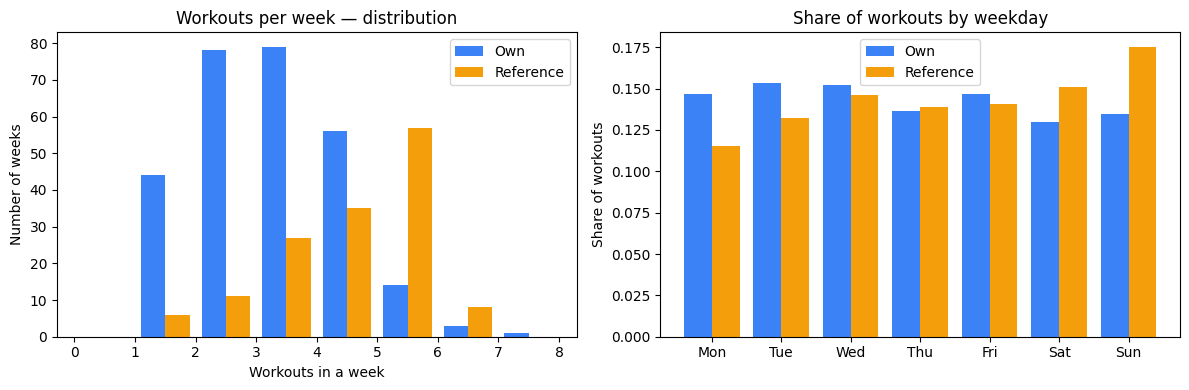

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = range(0, max(own_weekly.max(), ref_weekly.max()) + 2)
axes[0].hist([own_weekly, ref_weekly], bins=bins, label=["Own", "Reference"], color=["#3b82f6", "#f59e0b"])
axes[0].set_title("Workouts per week — distribution")
axes[0].set_xlabel("Workouts in a week")
axes[0].set_ylabel("Number of weeks")
axes[0].legend()

own_dow = own.groupby("workout_id")["day_of_week"].first().value_counts()
ref_dow = reference_sets.groupby("workout_id")["day_of_week"].first().value_counts()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
own_dow = own_dow.reindex(day_order, fill_value=0) / own_dow.sum()
ref_dow = ref_dow.reindex(day_order, fill_value=0) / ref_dow.sum()

x = np.arange(len(day_order))
axes[1].bar(x - 0.2, own_dow.values, width=0.4, label="Own", color="#3b82f6")
axes[1].bar(x + 0.2, ref_dow.values, width=0.4, label="Reference", color="#f59e0b")
axes[1].set_xticks(x)
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_title("Share of workouts by weekday")
axes[1].set_ylabel("Share of workouts")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Progression-shape comparison

Absolute 1RM isn't comparable (no bodyweight for the reference lifter), so instead compare
**trajectory shape**: each lifter's estimated 1RM indexed to their own peak (%), aligned by weeks
since their own first logged set of that exercise — not calendar date, since the two datasets are
about five years apart.

Two tiers, both shown, both driven by thresholds rather than a hardcoded exercise list:
- **Solid** (≥ 100 sets on both sides): the curve is based on enough data points to trust the shape.
- **Limited data** (30–99 sets on both sides): still informative, but each subplot says so explicitly
  — read these as a rough indication, not a confident trend.

In [11]:
MIN_SETS = 100

own_counts = own["exercise_name"].value_counts()
ref_counts = reference_sets["exercise_name"].value_counts()

overlap = pd.DataFrame({"own_sets": own_counts, "reference_sets": ref_counts}).dropna()
overlap["min_sets"] = overlap[["own_sets", "reference_sets"]].min(axis=1)
overlap = overlap.sort_values("min_sets", ascending=False)

shared_exercises = overlap[overlap["min_sets"] >= MIN_SETS].index.tolist()

print(f"Exercises with >= {MIN_SETS} sets on both sides:")
print(overlap.loc[shared_exercises].astype(int))


Exercises with >= 100 sets on both sides:
                             own_sets  reference_sets  min_sets
exercise_name                                                  
Bench Press (Barbell)             699             320       320
Squat (Barbell)                   266            1436       266
Bicep Curl (Barbell)              298             247       247
Romanian Deadlift (Barbell)       511             190       190
Deadlift (Barbell)                113             156       113


In [12]:
# Second tier: exercises with fewer sets are still worth showing, just flagged as
# limited data rather than silently included alongside the solid ones above.
LOW_DATA_MIN = 30

low_data_exercises = overlap[
    (overlap["min_sets"] >= LOW_DATA_MIN) & (overlap["min_sets"] < MIN_SETS)
].index.tolist()

print(f"Additional exercises with {LOW_DATA_MIN}-{MIN_SETS - 1} sets on both sides (limited data):")
print(overlap.loc[low_data_exercises].astype(int) if low_data_exercises else "(none)")

all_exercises = shared_exercises + low_data_exercises


Additional exercises with 30-99 sets on both sides (limited data):
                               own_sets  reference_sets  min_sets
exercise_name                                                    
Hack Squat                          316              58        58
Pull Up                             478              42        42
Incline Bench Press (Barbell)        36             779        36
Overhead Press (Dumbbell)           256              31        31


In [13]:
def normalized_progression(df: pd.DataFrame, exercise: str) -> pd.DataFrame:
    """Weekly best estimated_1rm for one exercise, indexed to % of peak and
    aligned to weeks since the lifter's own first logged set of that exercise."""
    ex = df[df["exercise_name"] == exercise].copy()
    start = ex["date"].min()
    ex["weeks_since_start"] = ((ex["date"] - start).dt.days // 7).astype(int)

    weekly_best = ex.groupby("weeks_since_start")["estimated_1rm"].max()
    peak = weekly_best.max()
    return (weekly_best / peak * 100).rename("pct_of_peak")


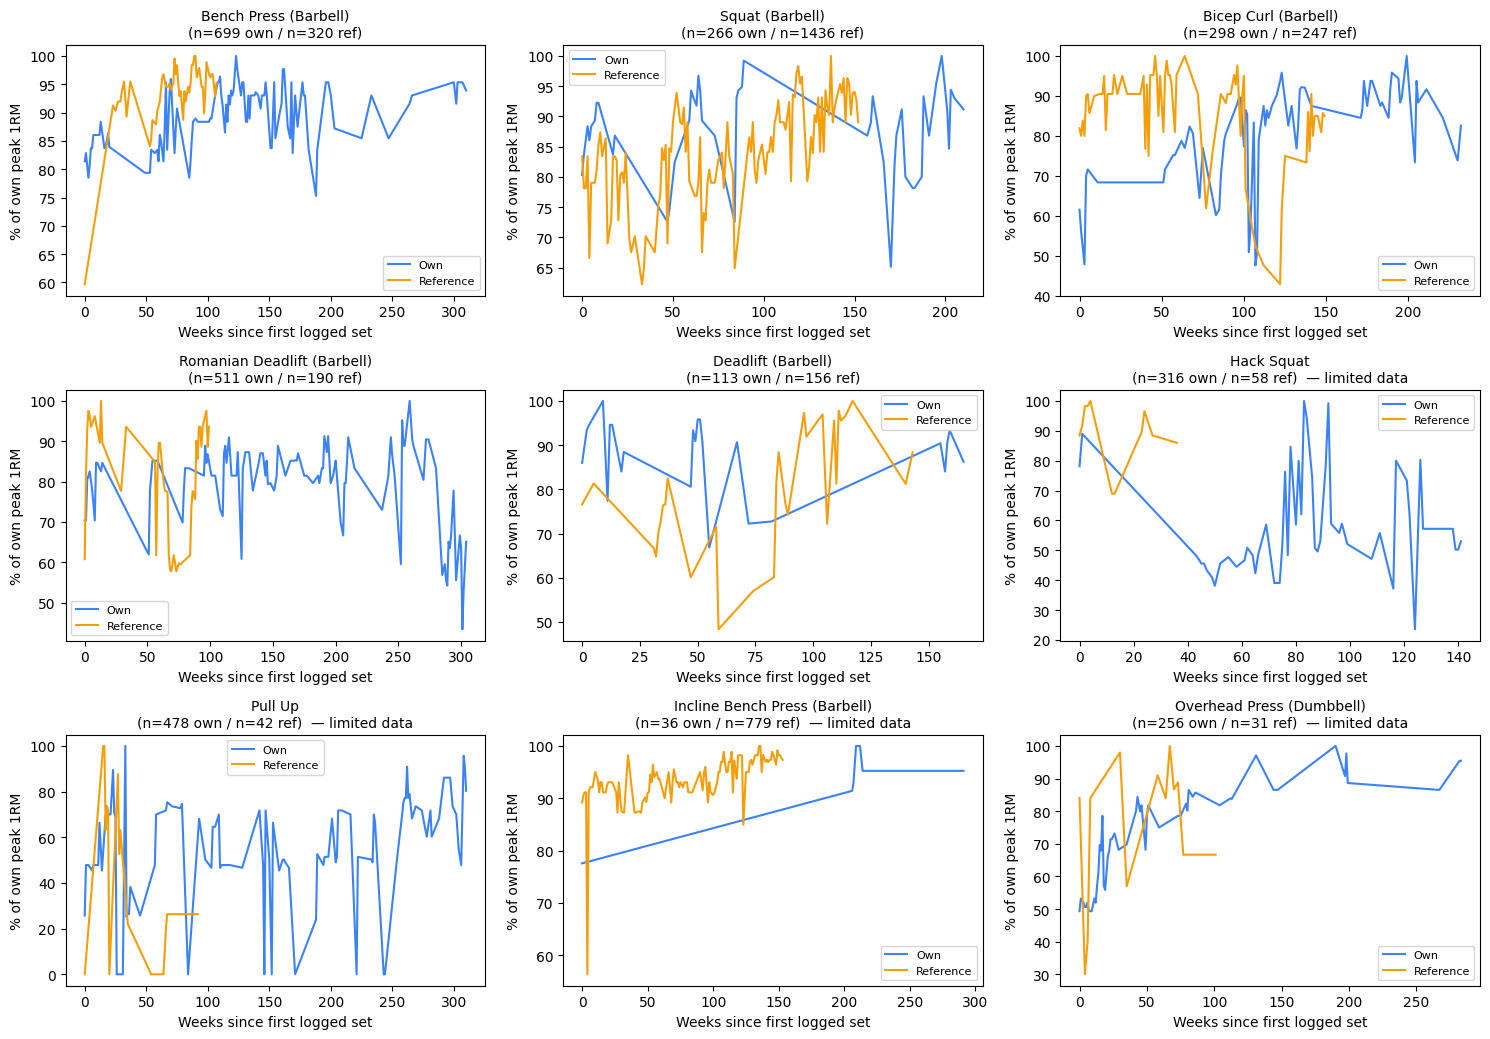

In [14]:
ncols = 3
nrows = -(-len(all_exercises) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, exercise in zip(axes_flat, all_exercises):
    own_curve = normalized_progression(own, exercise)
    ref_curve = normalized_progression(reference_sets, exercise)

    ax.plot(own_curve.index, own_curve.values, label="Own", color="#3b82f6")
    ax.plot(ref_curve.index, ref_curve.values, label="Reference", color="#f59e0b")

    own_n, ref_n = int(overlap.loc[exercise, "own_sets"]), int(overlap.loc[exercise, "reference_sets"])
    title = f"{exercise}\n(n={own_n} own / n={ref_n} ref)"
    if exercise in low_data_exercises:
        title += "  — limited data"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Weeks since first logged set")
    ax.set_ylabel("% of own peak 1RM")
    ax.legend(fontsize=8)

# Hide any unused grid cells (when all_exercises isn't a multiple of ncols)
for ax in axes_flat[len(all_exercises):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 5. Takeaways

**Frequency.** The reference lifter trained noticeably more often: 4.0 workouts/week on average
(median 4) vs. 2.75/week (median 3) for the own dataset, over a shorter overall time span (3 years
vs. 6). Neither lifter has a fixed "gym day": the own weekday distribution is almost uniform
(13.0–15.3% per day against 14.3% expected), and the reference lifter's is only slightly less so,
with a mild weekend lean (Sunday 17.5% vs. Monday 11.5%).

**Progression shape (solid data, ≥ 100 sets).** No single pattern wins across all five lifts — the
shape is lift-specific and person-specific, not a simple "more frequency = better shape" story:

- **Squat** looks similar for both: peak sits near the very end of each lifter's own timeline (94%
  and 90% of their full span), i.e. both were still trending upward when their data ends.
- **Bench Press** diverges: the own dataset peaks around 40% of the way through its span and settles
  at 94% of peak after that (a plateau), while the reference lifter's bench keeps climbing to a peak
  near the end of their data.
- **Bicep Curl** and **Romanian Deadlift** show the most contrast: the reference lifter peaks early
  (13–31% into their timeline) and holds that level, while the own dataset peaks very late but then
  drops off noticeably by the end (65% of peak for RDL) — consistent with a programming change or
  reduced focus on that lift late in the own dataset, not a strength loss narrative on its own.
- **Deadlift** is the starkest case: the own dataset's peak 1RM happens to fall in week 9 of a
  165-week span — an early outlier set rather than a representative trend — while the reference
  lifter shows a conventional late-peaking climb.

**Progression shape (limited data, 30–99 sets — treat as a rough indication only).**

- **Overhead Press** shows the closest match of any lift: both peak at roughly two-thirds through
  their timeline (67% and 66%).
- **Incline Bench Press** shows both still climbing late (72% and 88%), broadly consistent with the
  solid-data Bench Press pattern for the reference lifter.
- **Pull Up** is similar for both, and early for both: peak sits at 11% (own) and 16% (reference) of
  their respective timelines.
- **Hack Squat** shows the same early-vs-late split seen in Bicep Curl/RDL above: the reference
  lifter peaks almost immediately (11% in), while the own dataset peaks much later (59% in).

**Caveat.** These are two individuals with different programming, injury history, and (for the
reference lifter) unknown bodyweight — the frequency-vs-shape relationship observed here is
descriptive, not causal. The limited-data lifts in particular can shift with a single unusual
session, given how few points they're built from.